In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
zip_path <- "olist_geolocation_dataset.zip"
out_dir <- "."
unzip(zip_path, exdir = out_dir)

# Check what was extracted
list.files(out_dir, pattern = "\\.csv$", full.names = TRUE)

[1] "./olist_customers_dataset.csv"          
[2] "./olist_geolocation_dataset.csv"        
[3] "./olist_order_items_dataset.csv"        
[4] "./olist_order_payments_dataset.csv"     
[5] "./olist_order_reviews_dataset.csv"      
[6] "./olist_orders_dataset.csv"             
[7] "./olist_products_dataset.csv"           
[8] "./olist_sellers_dataset.csv"            
[9] "./product_category_name_translation.csv"

In [3]:
# Read the datasets
customers <- read_csv("./olist_customers_dataset.csv")
geolocation <- read_csv("./olist_geolocation_dataset.csv")
order_items <- read_csv("olist_order_items_dataset.csv")
payments <- read_csv("./olist_order_payments_dataset.csv")
reviews <- read_csv("./olist_order_reviews_dataset.csv")
orders <- read_csv("./olist_orders_dataset.csv")
products <- read_csv("olist_products_dataset.csv")
sellers <- read_csv("./olist_sellers_dataset.csv")
translations <- read_csv("product_category_name_translation.csv")

Rows: 99441 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): customer_id, customer_unique_id, customer_zip_code_prefix, customer...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1000163 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): geolocation_zip_code_prefix, geolocation_city, geolocation_state
dbl (2): geolocation_lat, geolocation_lng

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 112650 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): order_id, product_id, seller_id
dbl  (3): order_item_id, price, freight_value
dttm (1): shipping_limit_date

ℹ Use `spec()` 

In [4]:
summary(order_items)

   order_id         order_item_id     product_id         seller_id        
 Length:112650      Min.   : 1.000   Length:112650      Length:112650     
 Class :character   1st Qu.: 1.000   Class :character   Class :character  
 Mode  :character   Median : 1.000   Mode  :character   Mode  :character  
                    Mean   : 1.198                                        
                    3rd Qu.: 1.000                                        
                    Max.   :21.000                                        
 shipping_limit_date               price         freight_value   
 Min.   :2016-09-19 00:15:34   Min.   :   0.85   Min.   :  0.00  
 1st Qu.:2017-09-20 20:57:27   1st Qu.:  39.90   1st Qu.: 13.08  
 Median :2018-01-26 13:59:35   Median :  74.99   Median : 16.26  
 Mean   :2018-01-07 15:36:52   Mean   : 120.65   Mean   : 19.99  
 3rd Qu.:2018-05-10 14:34:00   3rd Qu.: 134.90   3rd Qu.: 21.15  
 Max.   :2020-04-09 22:35:08   Max.   :6735.00   Max.   :409.68  

In [5]:
summary(products)

  product_id        product_category_name product_name_lenght
 Length:32951       Length:32951          Min.   : 5.00      
 Class :character   Class :character      1st Qu.:42.00      
 Mode  :character   Mode  :character      Median :51.00      
                                          Mean   :48.48      
                                          3rd Qu.:57.00      
                                          Max.   :76.00      
                                          NA's   :610        
 product_description_lenght product_photos_qty product_weight_g
 Min.   :   4.0             Min.   : 1.000     Min.   :    0   
 1st Qu.: 339.0             1st Qu.: 1.000     1st Qu.:  300   
 Median : 595.0             Median : 1.000     Median :  700   
 Mean   : 771.5             Mean   : 2.189     Mean   : 2276   
 3rd Qu.: 972.0             3rd Qu.: 3.000     3rd Qu.: 1900   
 Max.   :3992.0             Max.   :20.000     Max.   :40425   
 NA's   :610                NA's   :610        NA's   :2

In [6]:
summary(translations)

 product_category_name product_category_name_english
 Length:71             Length:71                    
 Class :character      Class :character             
 Mode  :character      Mode  :character             

In [7]:
# Check customer data (IDs, zip codes, cities, states)
summary(customers)

# Check geolocation data (zip codes, lat/long coordinates)
summary(geolocation)

# Check payment data (payment types, installments, values)
summary(payments)

# Check review data (review scores, timestamps)
summary(reviews)

# Check core order data (order status, purchase timestamps, delivery dates)
summary(orders)

# Check seller data (seller IDs, zip codes, cities, states)
summary(sellers)

 customer_id        customer_unique_id customer_zip_code_prefix
 Length:99441       Length:99441       Length:99441            
 Class :character   Class :character   Class :character        
 Mode  :character   Mode  :character   Mode  :character        
 customer_city      customer_state    
 Length:99441       Length:99441      
 Class :character   Class :character  
 Mode  :character   Mode  :character  

 geolocation_zip_code_prefix geolocation_lat  geolocation_lng  
 Length:1000163              Min.   :-36.61   Min.   :-101.47  
 Class :character            1st Qu.:-23.60   1st Qu.: -48.57  
 Mode  :character            Median :-22.92   Median : -46.64  
                             Mean   :-21.18   Mean   : -46.39  
                             3rd Qu.:-19.98   3rd Qu.: -43.77  
                             Max.   : 45.07   Max.   : 121.11  
 geolocation_city   geolocation_state 
 Length:1000163     Length:1000163    
 Class :character   Class :character  
 Mode  :character   Mode  :character  
                                      
                                      
                                      

   order_id         payment_sequential payment_type       payment_installments
 Length:103886      Min.   : 1.000     Length:103886      Min.   : 0.000      
 Class :character   1st Qu.: 1.000     Class :character   1st Qu.: 1.000      
 Mode  :character   Median : 1.000     Mode  :character   Median : 1.000      
                    Mean   : 1.093                        Mean   : 2.853      
                    3rd Qu.: 1.000                        3rd Qu.: 4.000      
                    Max.   :29.000                        Max.   :24.000      
 payment_value     
 Min.   :    0.00  
 1st Qu.:   56.79  
 Median :  100.00  
 Mean   :  154.10  
 3rd Qu.:  171.84  
 Max.   :13664.08  

  review_id           order_id          review_score   review_comment_title
 Length:100000      Length:100000      Min.   :1.000   Length:100000       
 Class :character   Class :character   1st Qu.:4.000   Class :character    
 Mode  :character   Mode  :character   Median :5.000   Mode  :character    
                                       Mean   :4.071                       
                                       3rd Qu.:5.000                       
                                       Max.   :5.000                       
 review_comment_message review_creation_date         
 Length:100000          Min.   :2016-10-02 00:00:00  
 Class :character       1st Qu.:2017-09-23 00:00:00  
 Mode  :character       Median :2018-02-02 00:00:00  
                        Mean   :2018-01-12 17:58:10  
                        3rd Qu.:2018-05-15 00:00:00  
                        Max.   :2018-08-31 00:00:00  
 review_answer_timestamp      
 Min.   :2016-10-07 18:32:28  
 1st Qu.:2017-09-27 01:19:37

   order_id         customer_id        order_status      
 Length:99441       Length:99441       Length:99441      
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  
                                                         
                                                         
                                                         
                                                         
 order_purchase_timestamp      order_approved_at            
 Min.   :2016-09-04 21:15:19   Min.   :2016-09-15 12:16:38  
 1st Qu.:2017-09-12 14:46:19   1st Qu.:2017-09-12 23:24:16  
 Median :2018-01-18 23:04:36   Median :2018-01-19 11:36:13  
 Mean   :2017-12-31 08:43:12   Mean   :2017-12-31 18:35:24  
 3rd Qu.:2018-05-04 15:42:16   3rd Qu.:2018-05-04 20:35:10  
 Max.   :2018-10-17 17:30:18   Max.   :2018-09-03 17:40:06  
                               NA's   :160                  
 order_delivered_carrier_date  order_delivered_c

  seller_id         seller_zip_code_prefix seller_city       
 Length:3095        Length:3095            Length:3095       
 Class :character   Class :character       Class :character  
 Mode  :character   Mode  :character       Mode  :character  
 seller_state      
 Length:3095       
 Class :character  
 Mode  :character  

### Analysis

In [8]:
# Join items, products, translations, and orders
item_sales_data <- order_items %>%
  left_join(products, by = "product_id") %>%
  left_join(translations, by = "product_category_name") %>%
  left_join(orders, by = "order_id")

# Calculate total volume and isolate the Top 20
top_20_volume <- item_sales_data %>%
  # Filter out items that lack a category translation to keep our segments clean
  filter(!is.na(product_category_name_english)) %>%
  group_by(product_category_name_english) %>%
  summarise(total_purchased = n()) %>%
  arrange(desc(total_purchased)) %>%
  # Keep only the top 20
  head(20)

# View the pure volume ranking
print(top_20_volume)

# A tibble: 20 × 2
   product_category_name_english total_purchased
   <chr>                                   <int>
 1 bed_bath_table                          11115
 2 health_beauty                            9670
 3 sports_leisure                           8641
 4 furniture_decor                          8334
 5 computers_accessories                    7827
 6 housewares                               6964
 7 watches_gifts                            5991
 8 telephony                                4545
 9 garden_tools                             4347
10 auto                                     4235
11 toys                                     4117
12 cool_stuff                               3796
13 perfumery                                3419
14 baby                                     3065
15 electronics                              2767
16 stationery                               2517
17 fashion_bags_accessories                 2031
18 pet_shop                                 1947
1

In [9]:
# Analyze the status breakdown for the Top 20 segments
top_20_status_analysis <- item_sales_data %>%
  # Keep only the rows where the category is in our top 20 list
  filter(product_category_name_english %in% top_20_volume$product_category_name_english) %>%
  group_by(product_category_name_english) %>%
  summarise(
    total_purchased = n(),
    # Count how many successfully made it to the customer
    delivered_count = sum(order_status == "delivered", na.rm = TRUE),
    # Count cancellations and unavailable stock
    failed_count = sum(order_status %in% c("canceled", "unavailable"), na.rm = TRUE),
    # Calculate the failure rate as a percentage
    failure_rate_pct = round((failed_count / total_purchased) * 100, 2)
  ) %>%
  # Sort by total purchased to maintain the top 20 order
  arrange(desc(total_purchased))

# View the final analysis for Part 1
print(top_20_status_analysis)

# A tibble: 20 × 5
   product_category_name_english total_purchased delivered_count failed_count
   <chr>                                   <int>           <int>        <int>
 1 bed_bath_table                          11115           10953           18
 2 health_beauty                            9670            9465           36
 3 sports_leisure                           8641            8431           51
 4 furniture_decor                          8334            8160           36
 5 computers_accessories                    7827            7644           46
 6 housewares                               6964            6795           49
 7 watches_gifts                            5991            5859           21
 8 telephony                                4545            4430           18
 9 garden_tools                             4347            4268           19
10 auto                                     4235            4140           31
11 toys                                     4

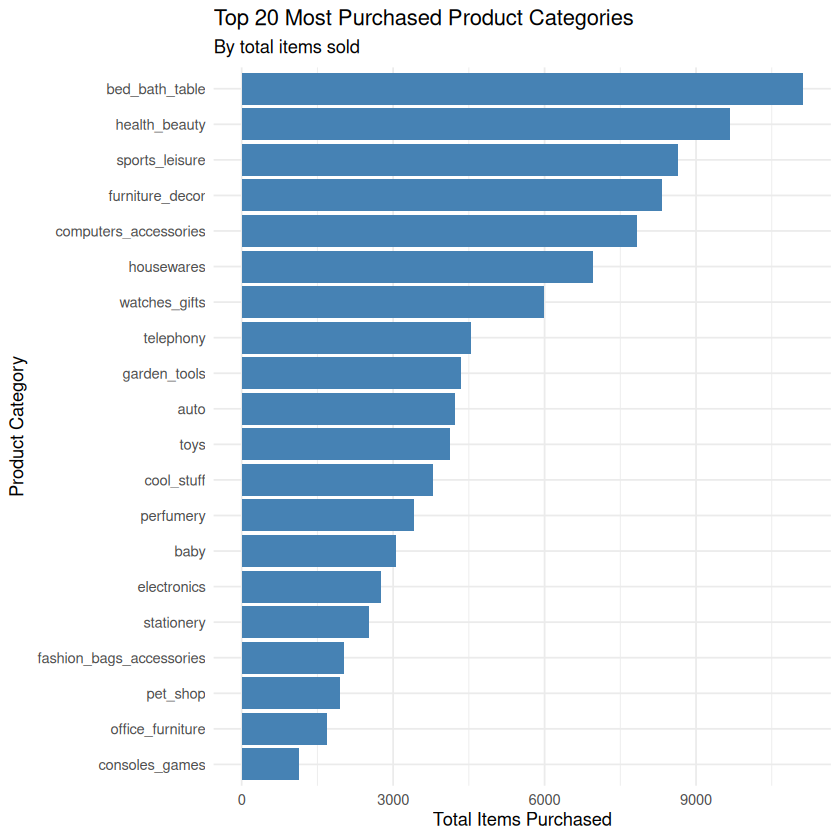

In [10]:
# Plot 1: Total Volume
ggplot(top_20_status_analysis, aes(x = reorder(product_category_name_english, total_purchased), y = total_purchased)) +
  # Use a nice blue color for volume
  geom_col(fill = "steelblue") +
  # Flip the coordinates so the long category names are readable on the left
  coord_flip() +
  # Add labels and titles
  labs(
    title = "Top 20 Most Purchased Product Categories",
    subtitle = "By total items sold",
    x = "Product Category",
    y = "Total Items Purchased"
  ) +
  # Use a clean, professional theme
  theme_minimal()

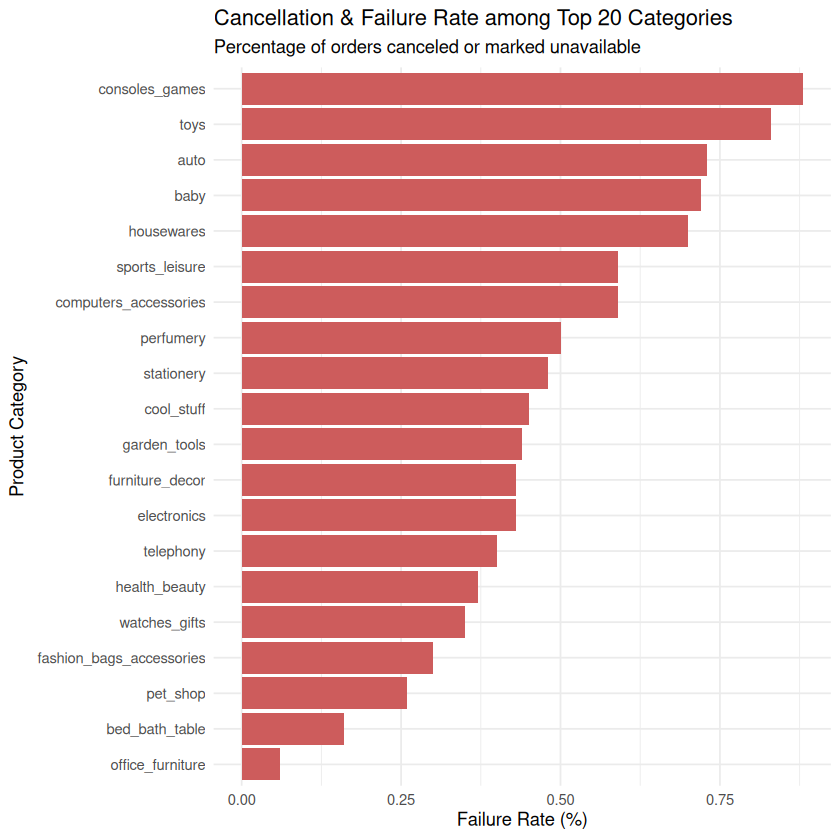

In [11]:
# Plot 2: Failure Rate Percentage
ggplot(top_20_status_analysis, aes(x = reorder(product_category_name_english, failure_rate_pct), y = failure_rate_pct)) +
  # Use a red color to indicate failure/cancellations
  geom_col(fill = "indianred") +
  coord_flip() +
  labs(
    title = "Cancellation & Failure Rate among Top 20 Categories",
    subtitle = "Percentage of orders canceled or marked unavailable",
    x = "Product Category",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()

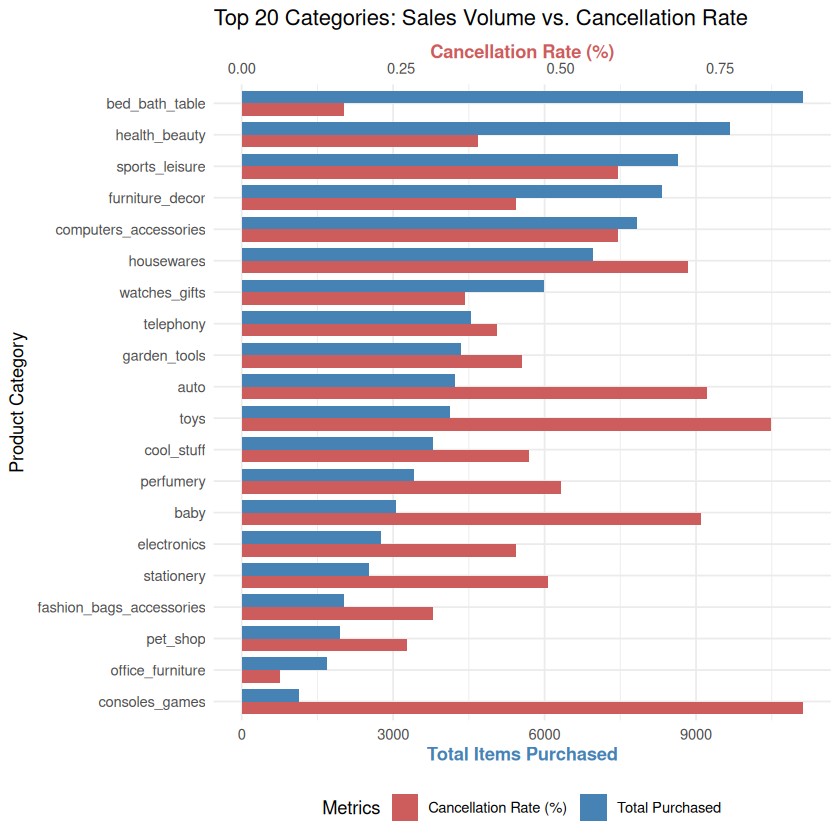

In [12]:
# 1. Calculate a scaling factor
# This aligns the small percentage numbers to the large volume numbers
scale_factor <- max(top_20_status_analysis$total_purchased) / max(top_20_status_analysis$failure_rate_pct)

# 2. Build the dual-axis plot
ggplot(top_20_status_analysis, aes(x = reorder(product_category_name_english, total_purchased))) +
  
  # Bar 1: Total Purchased (nudged slightly to one side)
  geom_col(aes(y = total_purchased, fill = "Total Purchased"), 
           position = position_nudge(x = 0.2), width = 0.4) +
           
  # Bar 2: Cancellation Rate (nudged to the other side, and scaled up by our factor)
  geom_col(aes(y = failure_rate_pct * scale_factor, fill = "Cancellation Rate (%)"), 
           position = position_nudge(x = -0.2), width = 0.4) +
           
  # Define the Dual Y-Axis
  scale_y_continuous(
    name = "Total Items Purchased",
    # The secondary axis divides by the scale_factor to show the true percentage
    sec.axis = sec_axis(~ . / scale_factor, name = "Cancellation Rate (%)")
  ) +
  
  # Set custom colors for the two metrics
  scale_fill_manual(
    name = "Metrics", 
    values = c("Total Purchased" = "steelblue", "Cancellation Rate (%)" = "indianred")
  ) +
  
  # Flip the chart so long category names are readable
  coord_flip() +
  
  # Add titles and clean up the theme
  labs(
    title = "Top 20 Categories: Sales Volume vs. Cancellation Rate",
    x = "Product Category"
  ) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    # Color the axis titles to match the bars for easier reading
    axis.title.x.bottom = element_text(color = "steelblue", face = "bold"),
    axis.title.x.top = element_text(color = "indianred", face = "bold")
  )

### Sentiment

In [13]:
# Join reviews and calculate sentiment percentages
sentiment_analysis <- item_sales_data %>%
  # Keep only our Top 20 categories
  filter(product_category_name_english %in% top_20_volume$product_category_name_english) %>%
  # Join with the reviews table
  inner_join(reviews, by = "order_id") %>%
  # Drop any missing review scores
  filter(!is.na(review_score)) %>%
  # Create a new sentiment column
  mutate(sentiment = case_when(
    review_score >= 4 ~ "Positive (4-5 Stars)",
    review_score == 3 ~ "Neutral (3 Stars)",
    review_score <= 2 ~ "Negative (1-2 Stars)"
  )) %>%
  # Group by category and sentiment
  group_by(product_category_name_english, sentiment) %>%
  summarise(review_count = n(), .groups = "drop_last") %>%
  # Calculate the percentage within each category
  mutate(percent = (review_count / sum(review_count)) * 100) %>%
  ungroup()

# View the raw numbers
head(sentiment_analysis)

Warning message in inner_join(., reviews, by = "order_id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 85 of `x` matches multiple rows in `y`.
ℹ Row 15367 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


product_category_name_english,sentiment,review_count,percent
<chr>,<chr>,<int>,<dbl>
auto,Negative (1-2 Stars),681,16.000940
auto,Neutral (3 Stars),322,7.565789
auto,Positive (4-5 Stars),3253,76.433271
baby,Negative (1-2 Stars),527,17.149365
baby,Neutral (3 Stars),263,8.558412
baby,Positive (4-5 Stars),2283,74.292223


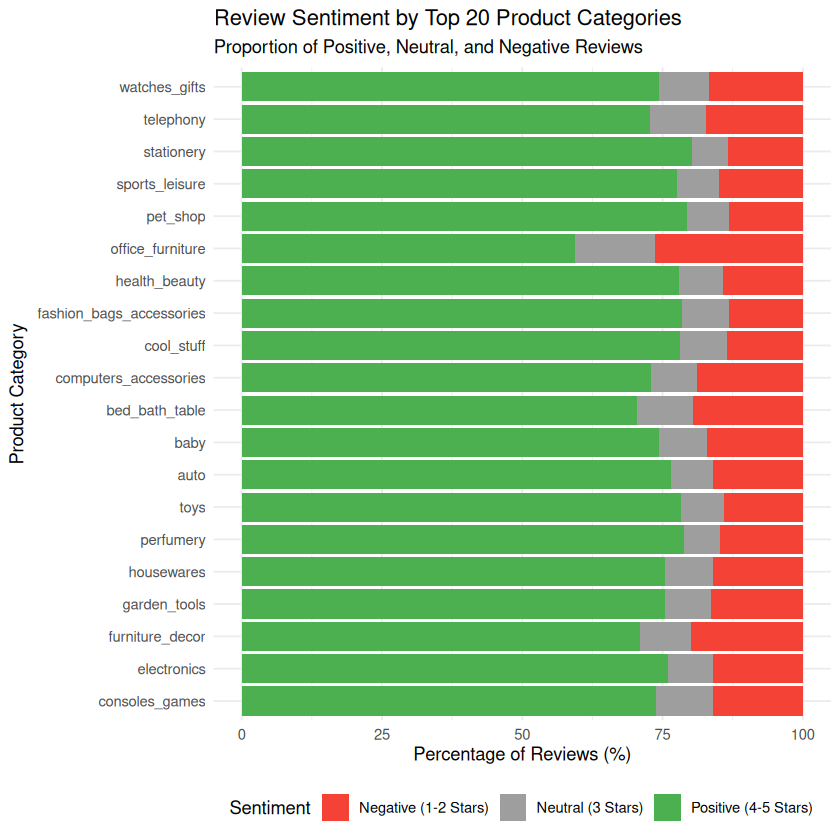

In [14]:
# Define a custom color palette (Green = Good, Grey = Neutral, Red = Bad)
sentiment_colors <- c("Positive (4-5 Stars)" = "#4CAF50", 
                      "Neutral (3 Stars)" = "#9E9E9E", 
                      "Negative (1-2 Stars)" = "#F44336")

# Create the stacked bar chart
ggplot(sentiment_analysis, aes(x = reorder(product_category_name_english, percent), 
                               y = percent, 
                               fill = sentiment)) +
  # Use position = "stack" to build the 100% bars
  geom_col(position = "stack") +
  coord_flip() +
  scale_fill_manual(values = sentiment_colors) +
  labs(
    title = "Review Sentiment by Top 20 Product Categories",
    subtitle = "Proportion of Positive, Neutral, and Negative Reviews",
    x = "Product Category",
    y = "Percentage of Reviews (%)",
    fill = "Sentiment"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

### Geographic Data

In [15]:
# Join sales data with customer locations
geo_analysis <- item_sales_data %>%
  # Keep only the Top 20 categories
  filter(product_category_name_english %in% top_20_volume$product_category_name_english) %>%
  # Bring in the customer location data
  left_join(customers, by = "customer_id") %>%
  # Group by category and state
  group_by(product_category_name_english, customer_state) %>%
  summarise(items_sold = n(), .groups = "drop") %>%
  # Calculate what percentage of the category's total sales went to each state
  group_by(product_category_name_english) %>%
  mutate(percent_of_category = (items_sold / sum(items_sold)) * 100) %>%
  ungroup()

# View the highest concentrations
head(geo_analysis %>% arrange(desc(percent_of_category)), 10)

product_category_name_english,customer_state,items_sold,percent_of_category
<chr>,<chr>,<int>,<dbl>
bed_bath_table,SP,5235,47.09852
housewares,SP,3265,46.88397
pet_shop,SP,898,46.12224
consoles_games,SP,496,43.62357
health_beauty,SP,4204,43.47466
perfumery,SP,1477,43.19977
sports_leisure,SP,3667,42.43722
fashion_bags_accessories,SP,861,42.39291
furniture_decor,SP,3531,42.36861


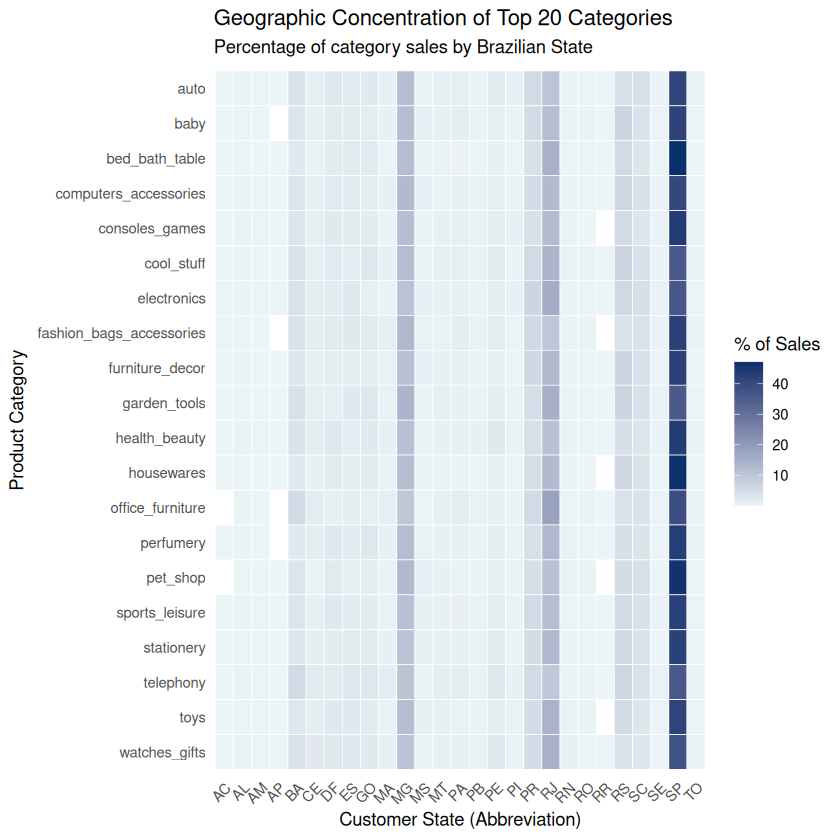

In [16]:
# Create a heatmap of geographic distribution
ggplot(geo_analysis, aes(x = customer_state, 
                         y = reorder(product_category_name_english, desc(product_category_name_english)), 
                         fill = percent_of_category)) +
  # Create the tiles and add a white border for a clean look
  geom_tile(color = "white") +
  # Use a color gradient from very light blue to deep blue
  scale_fill_gradient(low = "#ebf4f6", high = "#08306b", name = "% of Sales") +
  labs(
    title = "Geographic Concentration of Top 20 Categories",
    subtitle = "Percentage of category sales by Brazilian State",
    x = "Customer State (Abbreviation)",
    y = "Product Category"
  ) +
  theme_minimal() +
  # Tidy up the axes
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  )

### macro segments

In [17]:
# Group specific categories into broad Macro-Segments
segment_data <- item_sales_data %>%
  filter(!is.na(product_category_name_english)) %>%
  mutate(macro_segment = case_when(
    product_category_name_english %in% c("bed_bath_table", "furniture_decor", "housewares", "home_confort", "office_furniture", "home_construction") ~ "Home & Furniture",
    product_category_name_english %in% c("health_beauty", "perfumery", "fashion_bags_accessories", "watches_gifts", "luggage_accessories") ~ "Fashion & Beauty",
    product_category_name_english %in% c("computers_accessories", "telephony", "electronics", "consoles_games", "pc_gamer", "audio") ~ "Tech & Electronics",
    product_category_name_english %in% c("sports_leisure", "auto", "garden_tools", "toys", "musical_instruments") ~ "Sports, Auto & Leisure",
    product_category_name_english %in% c("baby", "stationery", "pet_shop", "books_general_interest") ~ "Family, Pets & Hobbies",
    # Catch everything else
    TRUE ~ "Other/Miscellaneous"
  )) %>%
  # Group by our new high-level segments
  group_by(macro_segment) %>%
  summarise(total_items_sold = n()) %>%
  # Calculate market share
  mutate(market_share_pct = round((total_items_sold / sum(total_items_sold)) * 100, 1)) %>%
  arrange(desc(total_items_sold))

# View the macro-segment breakdown
print(segment_data)

# A tibble: 6 × 3
  macro_segment          total_items_sold market_share_pct
  <chr>                             <int>            <dbl>
1 Home & Furniture                  29142             26.2
2 Fashion & Beauty                  22203             20  
3 Sports, Auto & Leisure            22020             19.8
4 Tech & Electronics                16640             15  
5 Other/Miscellaneous               12936             11.7
6 Family, Pets & Hobbies             8082              7.3


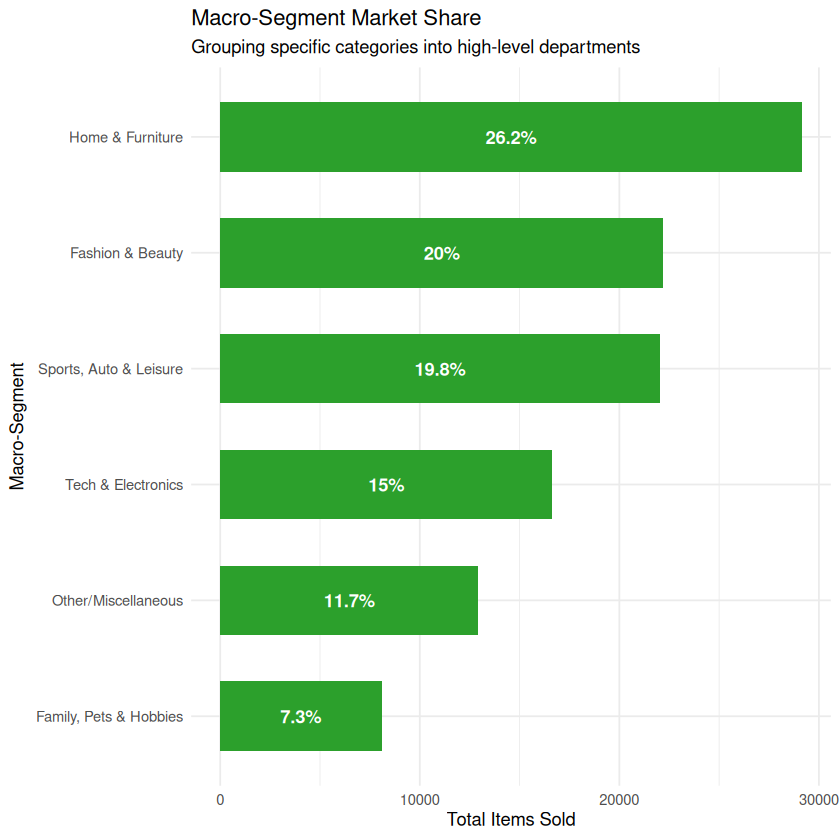

In [18]:
# Plot the Macro-Segments
ggplot(segment_data, aes(x = reorder(macro_segment, total_items_sold), y = total_items_sold)) +
  geom_col(fill = "#2CA02C", width = 0.6) +
  # Add text labels to show the percentage right on the bars
  geom_text(aes(label = paste0(market_share_pct, "%")), 
            position = position_stack(vjust = 0.5), 
            color = "white", fontface = "bold") +
  coord_flip() +
  labs(
    title = "Macro-Segment Market Share",
    subtitle = "Grouping specific categories into high-level departments",
    x = "Macro-Segment",
    y = "Total Items Sold"
  ) +
  theme_minimal()

### Vol and revenue

In [19]:
# Calculate Revenue, Volume, and Average Price
revenue_data <- item_sales_data %>%
  filter(!is.na(product_category_name_english)) %>%
  group_by(product_category_name_english) %>%
  summarise(
    total_revenue = sum(price, na.rm = TRUE),
    total_volume = n(),
    average_price = round(mean(price, na.rm = TRUE), 2)
  ) %>%
  # Sort by total revenue instead of volume
  arrange(desc(total_revenue)) %>%
  # Isolate the Top 20 Revenue Generators
  head(20)

# View the revenue leaders
print(revenue_data)

# A tibble: 20 × 4
   product_category_name_english total_revenue total_volume average_price
   <chr>                                 <dbl>        <int>         <dbl>
 1 health_beauty                      1258681.         9670         130. 
 2 watches_gifts                      1205006.         5991         201. 
 3 bed_bath_table                     1036989.        11115          93.3
 4 sports_leisure                      988049.         8641         114. 
 5 computers_accessories               911954.         7827         117. 
 6 furniture_decor                     729762.         8334          87.6
 7 cool_stuff                          635291.         3796         167. 
 8 housewares                          632249.         6964          90.8
 9 auto                                592720.         4235         140. 
10 garden_tools                        485256.         4347         112. 
11 toys                                483947.         4117         118. 
12 baby            

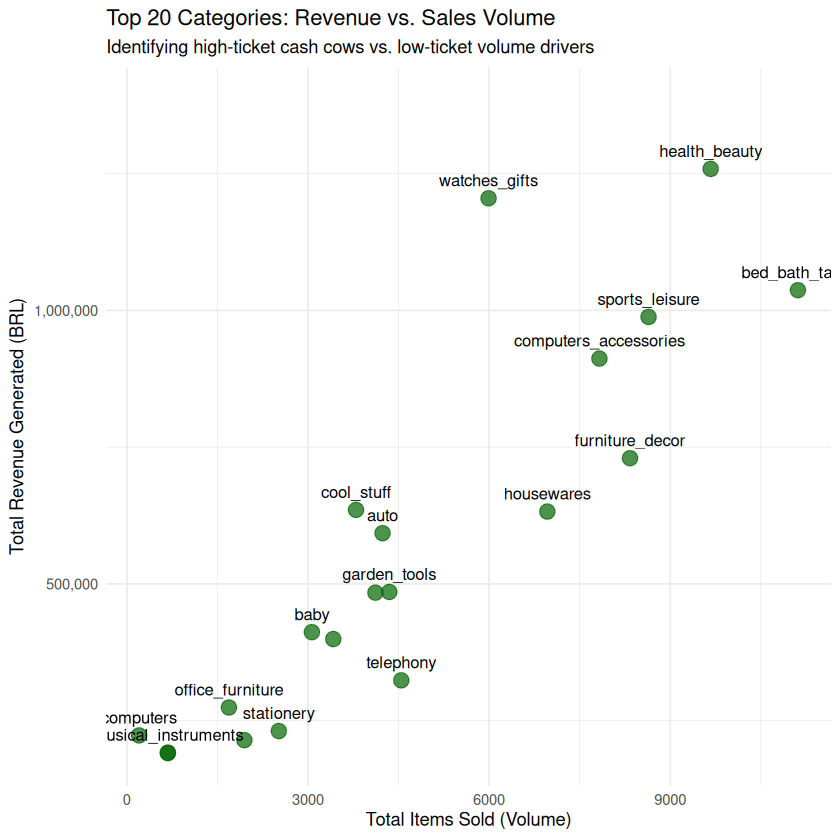

In [20]:
# Scatter Plot: Volume vs. Revenue
ggplot(revenue_data, aes(x = total_volume, y = total_revenue)) +
  # Add points for each category
  geom_point(color = "darkgreen", size = 4, alpha = 0.7) +
  # Add text labels so we know which dot is which category
  geom_text(aes(label = product_category_name_english), 
            vjust = -1, hjust = 0.5, size = 3.5, check_overlap = TRUE) +
  # Format the Y-axis to show normal numbers instead of scientific notation
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Top 20 Categories: Revenue vs. Sales Volume",
    subtitle = "Identifying high-ticket cash cows vs. low-ticket volume drivers",
    x = "Total Items Sold (Volume)",
    y = "Total Revenue Generated (BRL)"
  ) +
  theme_minimal() +
  # Expand the limits slightly so text labels don't get cut off at the top
  expand_limits(y = max(revenue_data$total_revenue) * 1.1)

### Frieght and Price

In [21]:
# Calculate the Freight Burden for the Top 20 Categories
logistics_analysis <- item_sales_data %>%
  # Keep only our Top 20 volume categories
  filter(product_category_name_english %in% top_20_volume$product_category_name_english) %>%
  group_by(product_category_name_english) %>%
  summarise(
    total_product_revenue = sum(price, na.rm = TRUE),
    total_freight_cost = sum(freight_value, na.rm = TRUE),
    # Calculate the average product price and average shipping cost
    avg_price = mean(price, na.rm = TRUE),
    avg_freight = mean(freight_value, na.rm = TRUE)
  ) %>%
  # Calculate the Freight Burden (% of the product price that shipping costs)
  mutate(freight_burden_pct = round((total_freight_cost / total_product_revenue) * 100, 1)) %>%
  # Sort to see which items are most weighed down by shipping costs
  arrange(desc(freight_burden_pct))

# View the results
print(logistics_analysis)

# A tibble: 20 × 6
   product_category_name_en…¹ total_product_revenue total_freight_cost avg_price
   <chr>                                      <dbl>              <dbl>     <dbl>
 1 electronics                              160247.             46578.      57.9
 2 office_furniture                         273961.             68572.     162. 
 3 furniture_decor                          729762.            172749.      87.6
 4 housewares                               632249.            146149.      90.8
 5 telephony                                323668.             71216.      71.2
 6 fashion_bags_accessories                 152824.             31450       75.2
 7 garden_tools                             485256.             98963.     112. 
 8 stationery                               230943.             46798.      91.8
 9 bed_bath_table                          1036989.            204693.      93.3
10 pet_shop                                 214315.             39561.     110. 
11 sports

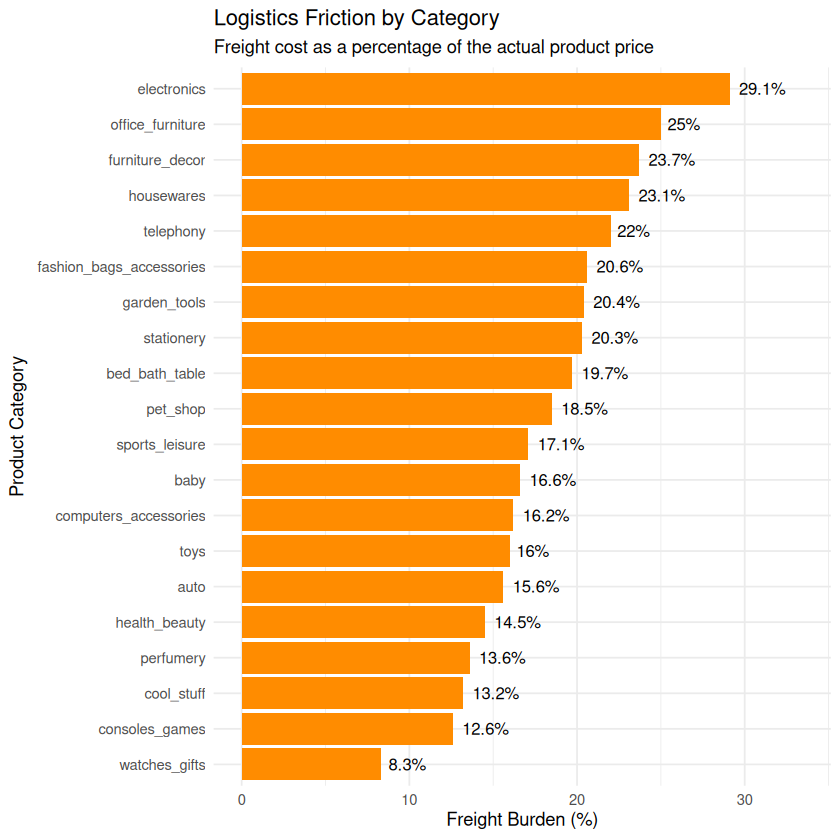

In [22]:
# Plot the Freight Burden
ggplot(logistics_analysis, aes(x = reorder(product_category_name_english, freight_burden_pct), y = freight_burden_pct)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  # Add text labels to show the exact percentage
  geom_text(aes(label = paste0(freight_burden_pct, "%")), 
            hjust = -0.2, color = "black", size = 3.5) +
  labs(
    title = "Logistics Friction by Category",
    subtitle = "Freight cost as a percentage of the actual product price",
    x = "Product Category",
    y = "Freight Burden (%)"
  ) +
  theme_minimal() +
  # Expand limits slightly so the text labels fit on the screen
  expand_limits(y = max(logistics_analysis$freight_burden_pct) * 1.15)

## Top 20 and Bottom 20

In [23]:
# 1. Get the total volume for all categories
all_volume <- item_sales_data %>%
  filter(!is.na(product_category_name_english)) %>%
  group_by(product_category_name_english) %>%
  summarise(total_purchased = n()) %>%
  arrange(desc(total_purchased))

# 2. Slice the Top 20 and Bottom 20, and label them
top_20_group <- head(all_volume, 20) %>% 
  mutate(performance_group = "Top 20 Categories")

bottom_20_group <- tail(all_volume, 20) %>% 
  mutate(performance_group = "Bottom 20 Categories")

# 3. Combine them into one target list
target_categories <- bind_rows(top_20_group, bottom_20_group)

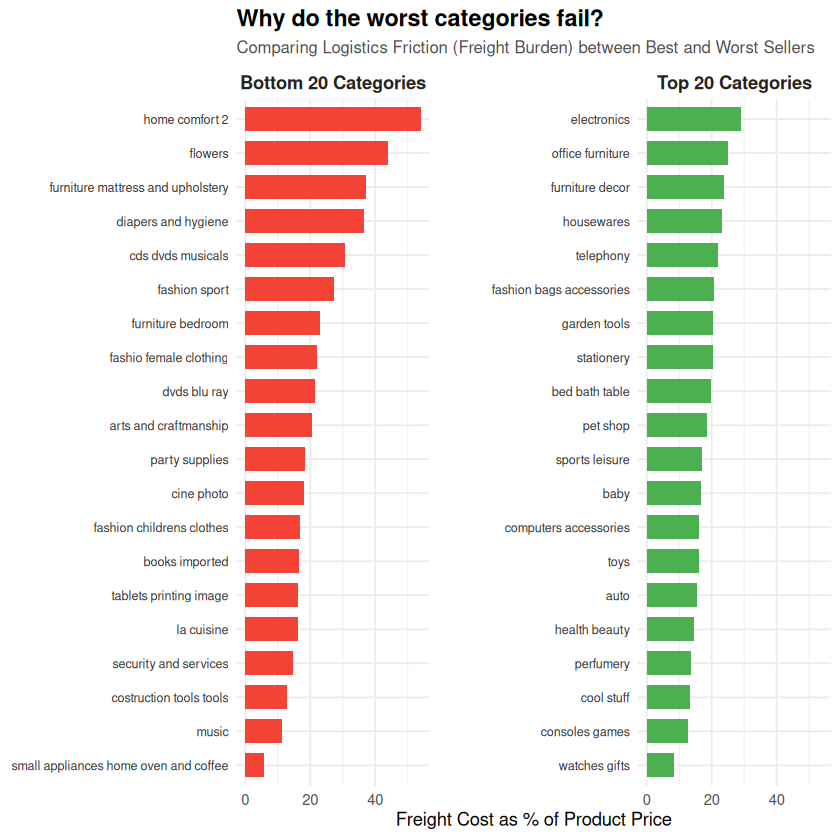

In [24]:
# 1. Prepare the data with clean category names
clean_comparison <- item_sales_data %>%
  inner_join(target_categories, by = "product_category_name_english") %>%
  group_by(product_category_name_english, performance_group) %>%
  summarise(
    total_revenue = sum(price, na.rm = TRUE),
    total_freight = sum(freight_value, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    freight_burden_pct = round((total_freight / total_revenue) * 100, 1),
    # Clean up underscores for better spacing and layout
    clean_category = gsub("_", " ", product_category_name_english)
  )

# 2. Plot with adjusted text hierarchy and spacing
ggplot(clean_comparison, aes(x = reorder(clean_category, freight_burden_pct), y = freight_burden_pct, fill = performance_group)) +
  # Slim down the bars slightly (width = 0.7) to create breathing room between rows
  geom_col(width = 0.7, show.legend = FALSE) +
  coord_flip() +
  # Force each facet to drop categories it doesn't own so there are no empty gaps
  facet_wrap(~ performance_group, scales = "free_y") +
  scale_fill_manual(values = c("Top 20 Categories" = "#4CAF50", "Bottom 20 Categories" = "#F44336")) +
  labs(
    title = "Why do the worst categories fail?",
    subtitle = "Comparing Logistics Friction (Freight Burden) between Best and Worst Sellers",
    x = NULL, # Remove redundant axis title since names speak for themselves
    y = "Freight Cost as % of Product Price"
  ) +
  theme_minimal() +
  theme(
    # Shrink the category text size so they never overlap
    axis.text.y = element_text(size = 7.5, color = "#333333"),
    # Add clear spacing between the two facet grids
    panel.spacing = unit(2.5, "lines"),
    # Stylize the facet headers
    strip.text = element_text(face = "bold", size = 11, color = "#222222"),
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 10, color = "gray30")
  )

In [25]:
# 1. Join sales, our target Top/Bottom lists, and reviews
review_comparison <- item_sales_data %>%
  # Keep only our Top 20 and Bottom 20 categories
  inner_join(target_categories, by = "product_category_name_english") %>%
  # Join with the reviews table
  inner_join(reviews, by = "order_id") %>%
  # Drop missing scores
  filter(!is.na(review_score)) %>%
  # Categorize the scores
  mutate(sentiment = case_when(
    review_score >= 4 ~ "Positive (4-5 Stars)",
    review_score == 3 ~ "Neutral (3 Stars)",
    review_score <= 2 ~ "Negative (1-2 Stars)"
  )) %>%
  # Group and calculate the percentages
  group_by(product_category_name_english, performance_group, sentiment) %>%
  summarise(review_count = n(), .groups = "drop_last") %>%
  mutate(
    percent = (review_count / sum(review_count)) * 100,
    clean_category = gsub("_", " ", product_category_name_english) # Clean text
  ) %>%
  ungroup()

# 2. Extract the Negative Review % so we can sort the chart by it
negative_sort <- review_comparison %>%
  filter(sentiment == "Negative (1-2 Stars)") %>%
  select(clean_category, negative_pct = percent)

# 3. Attach the sorting value back to the main data
review_comparison <- review_comparison %>%
  left_join(negative_sort, by = "clean_category") %>%
  # If a category has 0 negative reviews, fill the NA with 0
  mutate(negative_pct = replace_na(negative_pct, 0))

Warning message in inner_join(., reviews, by = "order_id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 85 of `x` matches multiple rows in `y`.
ℹ Row 15367 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


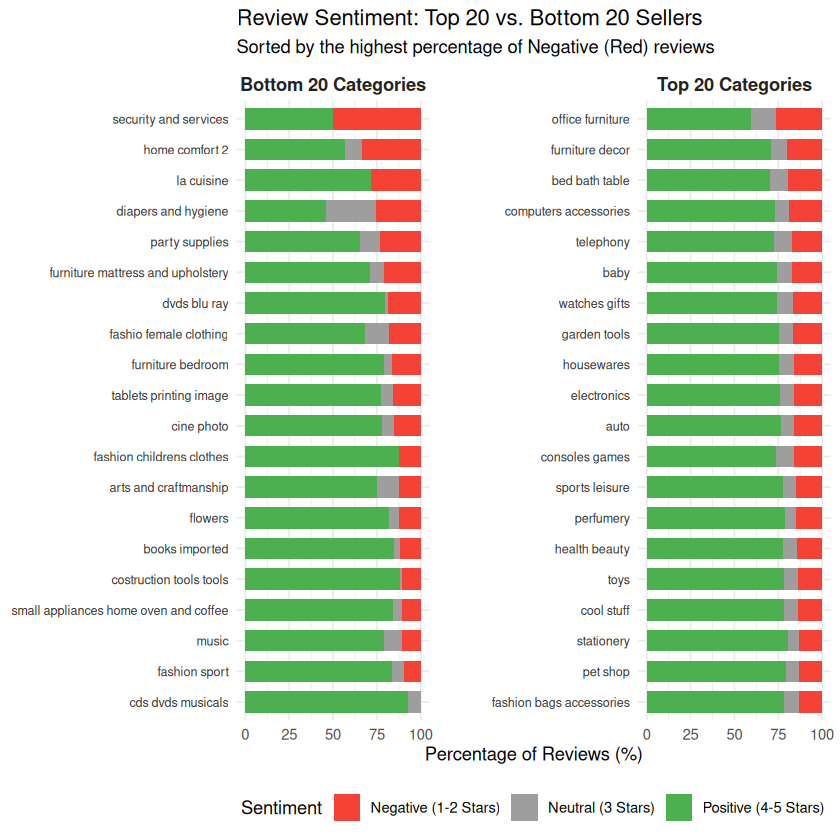

In [26]:
# Define our traffic light color scheme
sentiment_colors <- c("Positive (4-5 Stars)" = "#4CAF50", 
                      "Neutral (3 Stars)" = "#9E9E9E", 
                      "Negative (1-2 Stars)" = "#F44336")

# Plot using facet_wrap
ggplot(review_comparison, aes(x = reorder(clean_category, negative_pct), y = percent, fill = sentiment)) +
  # Use stack position for 100% bars, and width 0.7 for breathing room
  geom_col(position = "stack", width = 0.7) +
  coord_flip() +
  # Split into Top 20 and Bottom 20 panels
  facet_wrap(~ performance_group, scales = "free_y") +
  scale_fill_manual(values = sentiment_colors) +
  labs(
    title = "Review Sentiment: Top 20 vs. Bottom 20 Sellers",
    subtitle = "Sorted by the highest percentage of Negative (Red) reviews",
    x = NULL,
    y = "Percentage of Reviews (%)",
    fill = "Sentiment"
  ) +
  theme_minimal() +
  theme(
    # Keep the text size small to prevent overlapping
    axis.text.y = element_text(size = 7.5, color = "#333333"),
    panel.spacing = unit(2.5, "lines"),
    strip.text = element_text(face = "bold", size = 11, color = "#222222"),
    legend.position = "bottom"
  )

# Save the plot with plenty of vertical height
ggsave("review_comparison_plot.png", width = 11, height = 8.5, dpi = 300)

### dedupication

In [27]:
# 1. Clean the reviews table first so each order_id appears EXACTLY once
clean_reviews <- reviews %>%
  filter(!is.na(review_score)) %>%
  group_by(order_id) %>%
  # If an order has multiple reviews, take the average score
  summarise(review_score = mean(review_score), .groups = "drop")

# 2. Re-run the preparation with the deduplicated reviews
review_comparison <- item_sales_data %>%
  inner_join(target_categories, by = "product_category_name_english") %>%
  # Join with our clean, one-row-per-order reviews table
  inner_join(clean_reviews, by = "order_id") %>%
  # Categorize the scores safely
  mutate(sentiment = case_when(
    review_score >= 4 ~ "Positive (4-5 Stars)",
    review_score >= 2.5 & review_score < 4 ~ "Neutral (3 Stars)",
    review_score < 2.5 ~ "Negative (1-2 Stars)"
  )) %>%
  group_by(product_category_name_english, performance_group, sentiment) %>%
  summarise(review_count = n(), .groups = "drop_last") %>%
  mutate(
    percent = (review_count / sum(review_count)) * 100,
    clean_category = gsub("_", " ", product_category_name_english)
  ) %>%
  ungroup()

# 3. Extract the Negative Review % for perfect sorting
negative_sort <- review_comparison %>%
  filter(sentiment == "Negative (1-2 Stars)") %>%
  select(clean_category, negative_pct = percent)

review_comparison <- review_comparison %>%
  left_join(negative_sort, by = "clean_category") %>%
  mutate(negative_pct = replace_na(negative_pct, 0))

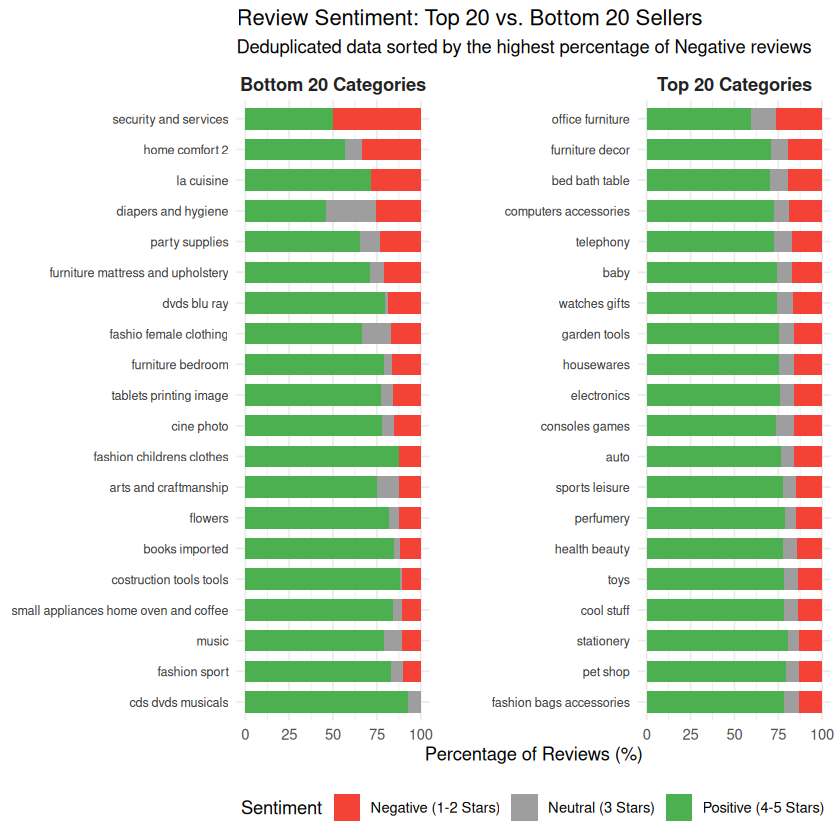

In [28]:
sentiment_colors <- c("Positive (4-5 Stars)" = "#4CAF50", 
                      "Neutral (3 Stars)" = "#9E9E9E", 
                      "Negative (1-2 Stars)" = "#F44336")

ggplot(review_comparison, aes(x = reorder(clean_category, negative_pct), y = percent, fill = sentiment)) +
  geom_col(position = "stack", width = 0.7) +
  coord_flip() +
  facet_wrap(~ performance_group, scales = "free_y") +
  scale_fill_manual(values = sentiment_colors) +
  labs(
    title = "Review Sentiment: Top 20 vs. Bottom 20 Sellers",
    subtitle = "Deduplicated data sorted by the highest percentage of Negative reviews",
    x = NULL,
    y = "Percentage of Reviews (%)",
    fill = "Sentiment"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 7.5, color = "#333333"),
    panel.spacing = unit(2.5, "lines"),
    strip.text = element_text(face = "bold", size = 11, color = "#222222"),
    legend.position = "bottom"
  )

ggsave("review_comparison_plot_clean.png", width = 11, height = 8.5, dpi = 300)

### additionals

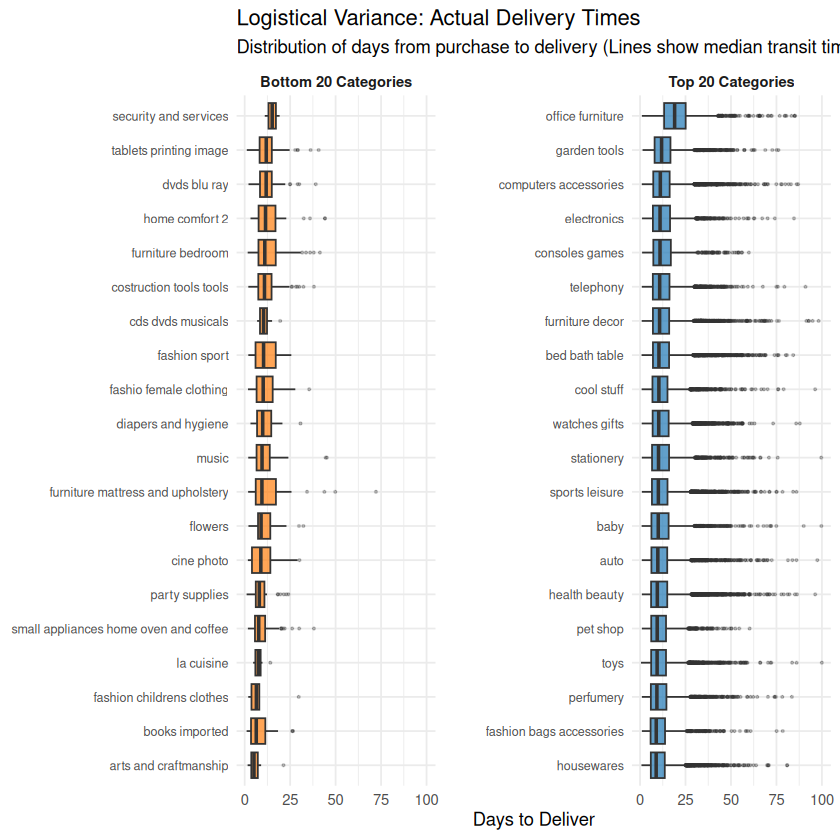

In [29]:
# 1. Calculate actual delivery duration in days
delivery_trends <- item_sales_data %>%
  inner_join(target_categories, by = "product_category_name_english") %>%
  # Filter for delivered orders with valid tracking dates
  filter(order_status == "delivered", 
         !is.na(order_delivered_customer_date), 
         !is.na(order_purchase_timestamp)) %>%
  mutate(
    # Calculate exact days from purchase to doorstep
    delivery_days = as.numeric(difftime(order_delivered_customer_date, 
                                        order_purchase_timestamp, 
                                        units = "days")),
    clean_category = gsub("_", " ", product_category_name_english)
  ) %>%
  # Filter out extreme anomalies/errors (e.g., negative days or > 100 days) to protect distribution
  filter(delivery_days >= 0 & delivery_days <= 100)

# 2. Plot logstical footprint using Box Plots
ggplot(delivery_trends, aes(x = reorder(clean_category, delivery_days, FUN = median), 
                            y = delivery_days, 
                            fill = performance_group)) +
  geom_boxplot(outlier.size = 0.5, outlier.alpha = 0.3, alpha = 0.7) +
  coord_flip() +
  facet_wrap(~ performance_group, scales = "free_y") +
  scale_fill_manual(values = c("Top 20 Categories" = "#1F77B4", "Bottom 20 Categories" = "#FF7F0E")) +
  labs(
    title = "Logistical Variance: Actual Delivery Times",
    subtitle = "Distribution of days from purchase to delivery (Lines show median transit time)",
    x = NULL,
    y = "Days to Deliver"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 7.5),
    panel.spacing = unit(2, "lines"),
    strip.text = element_text(face = "bold"),
    legend.position = "none"
  )

ggsave("delivery_variance_boxplot.png", width = 11, height = 8.5, dpi = 300)

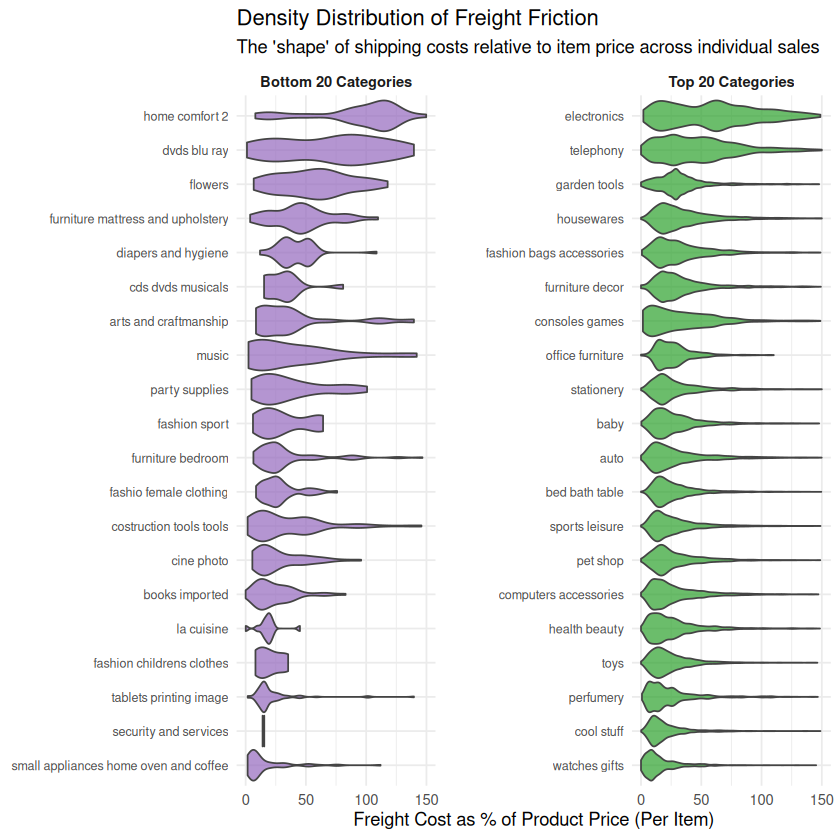

In [30]:
# 1. Calculate ratio per individual item row
friction_distribution <- item_sales_data %>%
  inner_join(target_categories, by = "product_category_name_english") %>%
  filter(!is.na(price) & price > 0) %>%
  mutate(
    individual_freight_ratio = (freight_value / price) * 100,
    clean_category = gsub("_", " ", product_category_name_english)
  ) %>%
  # Filter out massive anomalies where freight is 500%+ of price for clear viewing
  filter(individual_freight_ratio <= 150)

# 2. Plot using Violin distributions
ggplot(friction_distribution, aes(x = reorder(clean_category, individual_freight_ratio, FUN = median), 
                                  y = individual_freight_ratio, 
                                  fill = performance_group)) +
  # Violin geometry shows the shape of the data distribution
  geom_violin(scale = "width", alpha = 0.7, color = "#444444") +
  coord_flip() +
  facet_wrap(~ performance_group, scales = "free_y") +
  scale_fill_manual(values = c("Top 20 Categories" = "#2CA02C", "Bottom 20 Categories" = "#9467BD")) +
  labs(
    title = "Density Distribution of Freight Friction",
    subtitle = "The 'shape' of shipping costs relative to item price across individual sales",
    x = NULL,
    y = "Freight Cost as % of Product Price (Per Item)"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 7.5),
    panel.spacing = unit(2, "lines"),
    strip.text = element_text(face = "bold"),
    legend.position = "none"
  )

ggsave("freight_friction_violin.png", width = 11, height = 8.5, dpi = 300)

In [31]:
# Run a correlation matrix across operational metrics
statistical_summary <- item_sales_data %>%
  inner_join(target_categories, by = "product_category_name_english") %>%
  inner_join(clean_reviews, by = "order_id") %>%
  filter(!is.na(order_delivered_customer_date), !is.na(order_purchase_timestamp)) %>%
  mutate(
    delivery_days = as.numeric(difftime(order_delivered_customer_date, order_purchase_timestamp, units = "days")),
    freight_ratio = (freight_value / price) * 100
  ) %>%
  select(review_score, delivery_days, freight_ratio) %>%
  drop_na()

# Generate Pearson correlation matrix
cor_matrix <- cor(statistical_summary, method = "pearson")
print("--- Statistical Correlation Matrix ---")
print(cor_matrix)

[1] "--- Statistical Correlation Matrix ---"
              review_score delivery_days freight_ratio
review_score    1.00000000   -0.30708501   -0.04357279
delivery_days  -0.30708501    1.00000000    0.07643941
freight_ratio  -0.04357279    0.07643941    1.00000000


In [32]:
# Test 1: Is the relationship between Delivery Days and Review Score significant?
test_delivery_review <- cor.test(
  statistical_summary$delivery_days, 
  statistical_summary$review_score, 
  method = "pearson"
)

print("--- Significance Test: Delivery Days vs. Review Score ---")
print(test_delivery_review)

# Test 2: Is the relationship between Freight Ratio and Review Score significant?
test_freight_review <- cor.test(
  statistical_summary$freight_ratio, 
  statistical_summary$review_score, 
  method = "pearson"
)

print("--- Significance Test: Freight Ratio vs. Review Score ---")
print(test_freight_review)

[1] "--- Significance Test: Delivery Days vs. Review Score ---"

	Pearson's product-moment correlation

data:  statistical_summary$delivery_days and statistical_summary$review_score
t = -100.48, df = 96977, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.3127743 -0.3013737
sample estimates:
      cor 
-0.307085 

[1] "--- Significance Test: Freight Ratio vs. Review Score ---"

	Pearson's product-moment correlation

data:  statistical_summary$freight_ratio and statistical_summary$review_score
t = -13.582, df = 96977, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.04985288 -0.03728926
sample estimates:
        cor 
-0.04357279 



In [33]:
# Run statistical significance tests for each product category individually
category_statistical_tests <- item_sales_data %>%
  inner_join(target_categories, by = "product_category_name_english") %>%
  inner_join(clean_reviews, by = "order_id") %>%
  filter(!is.na(order_delivered_customer_date), !is.na(order_purchase_timestamp)) %>%
  mutate(
    delivery_days = as.numeric(difftime(order_delivered_customer_date, order_purchase_timestamp, units = "days")),
    freight_ratio = (freight_value / price) * 100,
    clean_category = gsub("_", " ", product_category_name_english)
  ) %>%
  group_by(clean_category, performance_group) %>%
  # Filter out categories with too few rows to ensure statistical validity (minimum 10 observations)
  filter(n() >= 10) %>%
  summarise(
    sample_size = n(),
    
    # 1. Delivery Days vs Review Score
    delivery_correlation = cor(delivery_days, review_score, method = "pearson"),
    delivery_p_value = cor.test(delivery_days, review_score, method = "pearson")$p.value,
    
    # 2. Freight Ratio vs Review Score
    freight_correlation = cor(freight_ratio, review_score, method = "pearson"),
    freight_p_value = cor.test(freight_ratio, review_score, method = "pearson")$p.value,
    
    .groups = "drop"
  ) %>%
  # Create simple tags to easily identify statistical significance
  mutate(
    delivery_significant = ifelse(delivery_p_value < 0.05, "Yes", "No"),
    freight_significant = ifelse(freight_p_value < 0.05, "Yes", "No")
  )

# View the categories most damaged by delivery delays
category_statistical_tests %>% 
  select(clean_category, performance_group, sample_size, delivery_correlation, delivery_significant) %>%
  arrange(delivery_correlation) %>% 
  head(40)

clean_category,performance_group,sample_size,delivery_correlation,delivery_significant
<chr>,<chr>,<int>,<dbl>,<chr>
furniture mattress and upholstery,Bottom 20 Categories,37,-0.5464819,Yes
music,Bottom 20 Categories,38,-0.5275307,Yes
tablets printing image,Bottom 20 Categories,83,-0.4814741,Yes
furniture bedroom,Bottom 20 Categories,103,-0.4379041,Yes
home comfort 2,Bottom 20 Categories,30,-0.4004820,Yes
fashion sport,Bottom 20 Categories,29,-0.3801624,Yes
arts and craftmanship,Bottom 20 Categories,24,-0.3760166,No
toys,Top 20 Categories,4030,-0.3738477,Yes
baby,Top 20 Categories,2982,-0.3659813,Yes


In [34]:
# Run statistical significance tests (Spearman) for each product category
category_statistical_tests <- item_sales_data %>%
  inner_join(target_categories, by = "product_category_name_english") %>%
  inner_join(clean_reviews, by = "order_id") %>%
  filter(!is.na(order_delivered_customer_date), !is.na(order_purchase_timestamp)) %>%
  mutate(
    delivery_days = as.numeric(difftime(order_delivered_customer_date, order_purchase_timestamp, units = "days")),
    freight_ratio = (freight_value / price) * 100,
    clean_category = gsub("_", " ", product_category_name_english)
  ) %>%
  group_by(clean_category, performance_group) %>%
  # Filter out categories with too few rows (minimum 10 observations)
  filter(n() >= 10) %>%
  summarise(
    sample_size = n(),
    
    # 1. Delivery Days vs Review Score (Non-parametric Spearman)
    delivery_correlation = cor(delivery_days, review_score, method = "spearman"),
    delivery_p_value = suppressWarnings(cor.test(delivery_days, review_score, method = "spearman")$p.value),
    
    # 2. Freight Ratio vs Review Score (Non-parametric Spearman) - Restored!
    freight_correlation = cor(freight_ratio, review_score, method = "spearman"),
    freight_p_value = suppressWarnings(cor.test(freight_ratio, review_score, method = "spearman")$p.value),
    
    .groups = "drop"
  ) %>%
  # Create simple tags to easily identify statistical significance
  mutate(
    delivery_significant = ifelse(delivery_p_value < 0.05, "Yes", "No"),
    freight_significant = ifelse(freight_p_value < 0.05, "Yes", "No")
  )

# View the clean results
category_statistical_tests %>% 
  select(clean_category, performance_group, sample_size, delivery_correlation, delivery_significant) %>%
  arrange(delivery_correlation) %>% 
  head(40)

clean_category,performance_group,sample_size,delivery_correlation,delivery_significant
<chr>,<chr>,<int>,<dbl>,<chr>
cds dvds musicals,Bottom 20 Categories,14,-0.60565370,Yes
furniture mattress and upholstery,Bottom 20 Categories,37,-0.49994156,Yes
tablets printing image,Bottom 20 Categories,83,-0.40962083,Yes
furniture bedroom,Bottom 20 Categories,103,-0.38113058,Yes
home comfort 2,Bottom 20 Categories,30,-0.34640568,No
diapers and hygiene,Bottom 20 Categories,37,-0.30112768,No
fashion sport,Bottom 20 Categories,29,-0.29970395,No
baby,Top 20 Categories,2982,-0.27764289,Yes
party supplies,Bottom 20 Categories,42,-0.27705742,No


### Seller Analysis

In [35]:
# 1. Identify the worst sellers in the problematic categories
seller_accountability <- item_sales_data %>%
  # Focus only on the Bottom 20 categories we identified
  inner_join(target_categories %>% filter(performance_group == "Bottom 20 Categories"), 
             by = "product_category_name_english") %>%
  filter(!is.na(order_delivered_customer_date), !is.na(order_purchase_timestamp)) %>%
  mutate(
    delivery_days = as.numeric(difftime(order_delivered_customer_date, order_purchase_timestamp, units = "days")),
    clean_category = gsub("_", " ", product_category_name_english)
  ) %>%
  group_by(clean_category, seller_id) %>%
  summarise(
    total_items_sold = n(),
    avg_delivery_days = round(mean(delivery_days, na.rm = TRUE), 1),
    .groups = "drop"
  ) %>%
  # Filter for sellers who actually have enough volume to make an impact (e.g., > 10 items)
  filter(total_items_sold > 10) %>%
  arrange(desc(avg_delivery_days))

# 2. View the absolute worst offenders
print("--- The 20 Worst Performing Sellers in Failing Categories ---")
head(seller_accountability, 20)

[1] "--- The 20 Worst Performing Sellers in Failing Categories ---"


clean_category,seller_id,total_items_sold,avg_delivery_days
<chr>,<chr>,<int>,<dbl>
costruction tools tools,c8467937e403e76a8ee9f0ab13f6f5ef,33,16.7
tablets printing image,e62b2d6ac10570a035a30bafcf01d263,20,16.2
fashio female clothing,dc8798cbf453b7e0f98745e396cc5616,12,15.8
home comfort 2,4a3ca9315b744ce9f8e9374361493884,26,15.4
cine photo,8d956fec2e4337affcb520f56fd8cbfd,12,15.2
small appliances home oven and coffee,f62d7bb4a613ec758a03342d46b580b2,19,14.5
furniture bedroom,3ade81dab5a172b88e1871c28ae05260,27,14.1
dvds blu ray,75fbb52eda0cbc24f479d3b2fbfa8d3e,41,13.9
furniture mattress and upholstery,00ee68308b45bc5e2660cd833c3f81cc,22,12.4


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


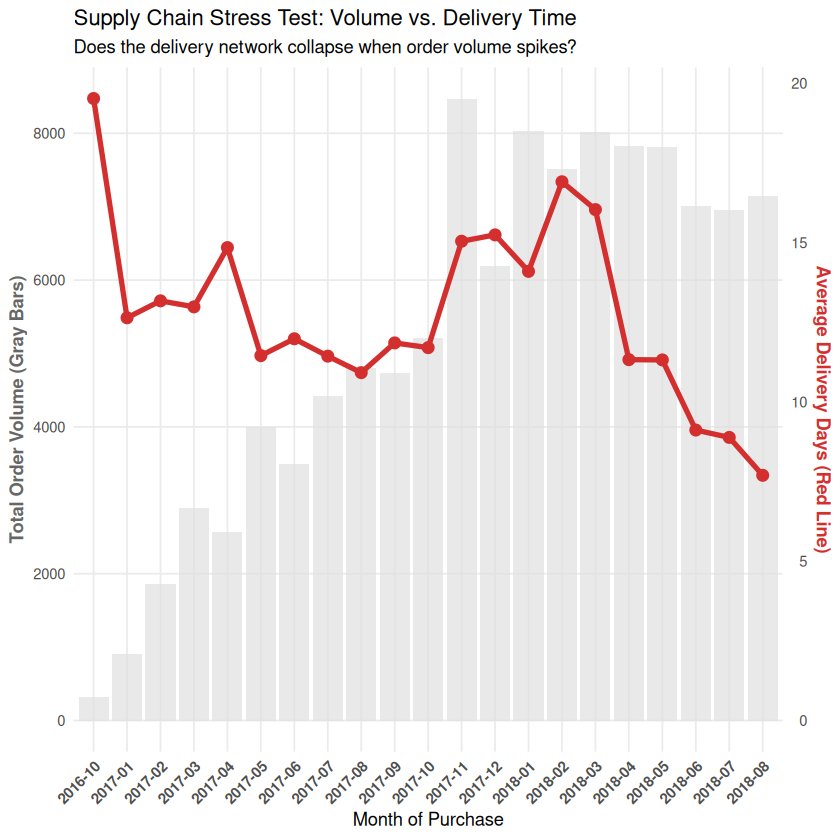

In [36]:
# 1. Prepare time-series data for seasonality
seasonality_trends <- item_sales_data %>%
  filter(!is.na(order_delivered_customer_date), !is.na(order_purchase_timestamp)) %>%
  mutate(
    # Extract just the Year and Month (e.g., "2017-11")
    purchase_month = format(as.Date(order_purchase_timestamp), "%Y-%m"),
    delivery_days = as.numeric(difftime(order_delivered_customer_date, order_purchase_timestamp, units = "days"))
  ) %>%
  group_by(purchase_month) %>%
  summarise(
    total_orders = n(),
    avg_delivery_time = mean(delivery_days, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  # Sort chronologically
  arrange(purchase_month) %>%
  # Filter out partial edge-case months that might skew the data (optional, but good practice)
  filter(total_orders > 100)

# 2. Plot the Seasonality Trend
# Note: We are scaling the delivery time up mathematically just for visual comparison on the same chart
scale_factor <- max(seasonality_trends$total_orders) / max(seasonality_trends$avg_delivery_time)

ggplot(seasonality_trends, aes(x = purchase_month, group = 1)) +
  # Bar chart for Order Volume (Background)
  geom_col(aes(y = total_orders), fill = "#E0E0E0", alpha = 0.7) +
  # Line chart for Delivery Days (Foreground)
  geom_line(aes(y = avg_delivery_time * scale_factor), color = "#D32F2F", size = 1.5) +
  geom_point(aes(y = avg_delivery_time * scale_factor), color = "#D32F2F", size = 3) +
  # Create two Y-axes so both metrics are readable
  scale_y_continuous(
    name = "Total Order Volume (Gray Bars)",
    sec.axis = sec_axis(~ . / scale_factor, name = "Average Delivery Days (Red Line)")
  ) +
  labs(
    title = "Supply Chain Stress Test: Volume vs. Delivery Time",
    subtitle = "Does the delivery network collapse when order volume spikes?",
    x = "Month of Purchase"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.title.y.left = element_text(color = "gray40", face = "bold"),
    axis.title.y.right = element_text(color = "#D32F2F", face = "bold"),
    panel.grid.minor = element_blank()
  )

ggsave("seasonality_stress_test.png", width = 12, height = 6, dpi = 300)

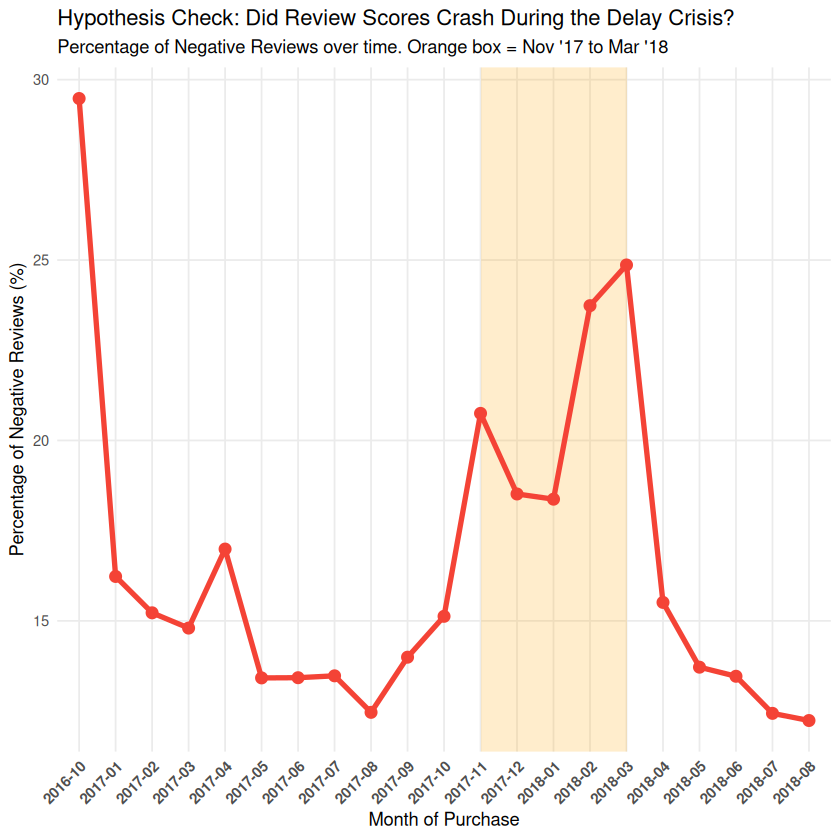

In [37]:
# 1. Calculate the percentage of negative reviews by month
sentiment_over_time <- item_sales_data %>%
  # Make sure we have dates
  filter(!is.na(order_purchase_timestamp)) %>%
  # Join with our deduplicated reviews table
  inner_join(clean_reviews, by = "order_id") %>%
  mutate(
    purchase_month = format(as.Date(order_purchase_timestamp), "%Y-%m"),
    # Flag negative reviews (1 or 2 stars)
    is_negative = ifelse(review_score <= 2, 1, 0)
  ) %>%
  group_by(purchase_month) %>%
  summarise(
    total_reviews = n(),
    negative_reviews = sum(is_negative),
    # Calculate the exact percentage of angry customers
    pct_negative = (negative_reviews / total_reviews) * 100,
    .groups = "drop"
  ) %>%
  # Filter out low-volume early months to keep the trend accurate
  filter(total_reviews > 100) %>% 
  arrange(purchase_month)

# 2. Plot the hypothesis check
ggplot(sentiment_over_time, aes(x = purchase_month, y = pct_negative, group = 1)) +
  # Add a shaded orange box over our suspected "Logistics Collapse" window
  annotate("rect", xmin = "2017-11", xmax = "2018-03", ymin = -Inf, ymax = Inf, 
           alpha = 0.2, fill = "orange") +
  # Draw the trend line
  geom_line(color = "#F44336", size = 1.5) +
  geom_point(color = "#F44336", size = 3) +
  labs(
    title = "Hypothesis Check: Did Review Scores Crash During the Delay Crisis?",
    subtitle = "Percentage of Negative Reviews over time. Orange box = Nov '17 to Mar '18",
    x = "Month of Purchase",
    y = "Percentage of Negative Reviews (%)"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    panel.grid.minor = element_blank()
  )

ggsave("sentiment_hypothesis_check.png", width = 12, height = 6, dpi = 300)

### Clustering

##### Unsupervised

In [38]:
# 1. Prepare the Data for the Algorithm
ml_data <- item_sales_data %>%
  filter(!is.na(price), !is.na(freight_value), !is.na(order_delivered_customer_date), !is.na(order_purchase_timestamp)) %>%
  mutate(
    delivery_days = as.numeric(difftime(order_delivered_customer_date, order_purchase_timestamp, units = "days"))
  ) %>%
  # Select purely numerical features for the math
  select(order_id, price, freight_value, delivery_days) %>%
  # Remove massive anomalies (e.g., $5000 items or 150-day delays) that destroy ML centroids
  filter(price < 1000, freight_value < 100, delivery_days > 0 & delivery_days < 60) %>%
  drop_na()

# 2. Scale the Data (CRITICAL STEP)
# K-Means uses "Euclidean Distance". If we don't scale, Price (often 100+) 
# will completely overpower Delivery Days (often < 15). 
ml_features <- ml_data %>% select(price, freight_value, delivery_days)
scaled_features <- scale(ml_features)

# 3. Train the K-Means Model
set.seed(42) # Locks the random number generator so your results are reproducible
# We are telling the AI to find exactly 3 distinct business profiles (centers = 3)
kmeans_model <- kmeans(scaled_features, centers = 3, nstart = 25)

# 4. Attach the ML predictions back to our human-readable data
ml_data$cluster_id <- as.factor(kmeans_model$cluster)

# 5. Decode the ML Clusters for the Business Team
cluster_summary <- ml_data %>%
  group_by(cluster_id) %>%
  summarise(
    total_sales = n(),
    avg_price = round(mean(price), 2),
    avg_freight = round(mean(freight_value), 2),
    avg_delivery_days = round(mean(delivery_days), 1),
    freight_burden_pct = round((mean(freight_value) / mean(price)) * 100, 1)
  ) %>%
  arrange(avg_price)

print("--- K-Means Clustering Results: Transaction Personas ---")
print(cluster_summary)

[1] "--- K-Means Clustering Results: Transaction Personas ---"
# A tibble: 3 × 6
  cluster_id total_sales avg_price avg_freight avg_delivery_days
  <fct>            <int>     <dbl>       <dbl>             <dbl>
1 3                77357      80.4        15.2               8.7
2 2                20598      93.0        21.4              24.8
3 1                10593     333.         42.4              13.5
# ℹ 1 more variable: freight_burden_pct <dbl>


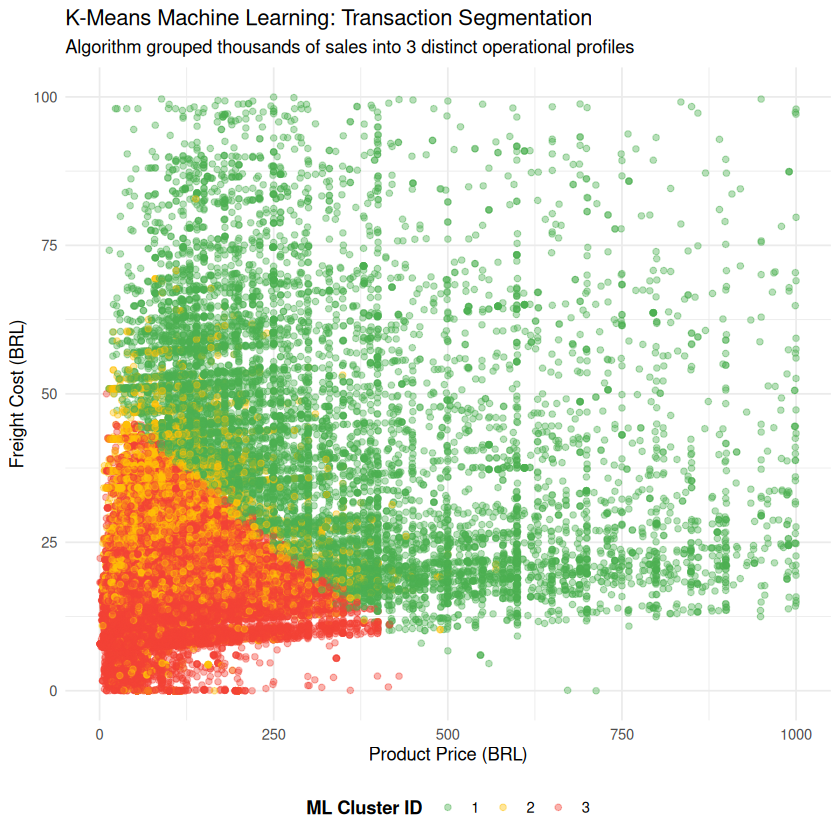

In [39]:
ggplot(ml_data, aes(x = price, y = freight_value, color = cluster_id)) +
  geom_point(alpha = 0.4, size = 1.5) +
  scale_color_manual(values = c("1" = "#4CAF50", "2" = "#FFC107", "3" = "#F44336")) +
  labs(
    title = "K-Means Machine Learning: Transaction Segmentation",
    subtitle = "Algorithm grouped thousands of sales into 3 distinct operational profiles",
    x = "Product Price (BRL)",
    y = "Freight Cost (BRL)",
    color = "ML Cluster ID"
  ) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold")
  )

ggsave("kmeans_sales_clusters.png", width = 10, height = 7, dpi = 300)

##### Supervised

In [41]:
install.packages("randomForest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Training the Random Forest..."


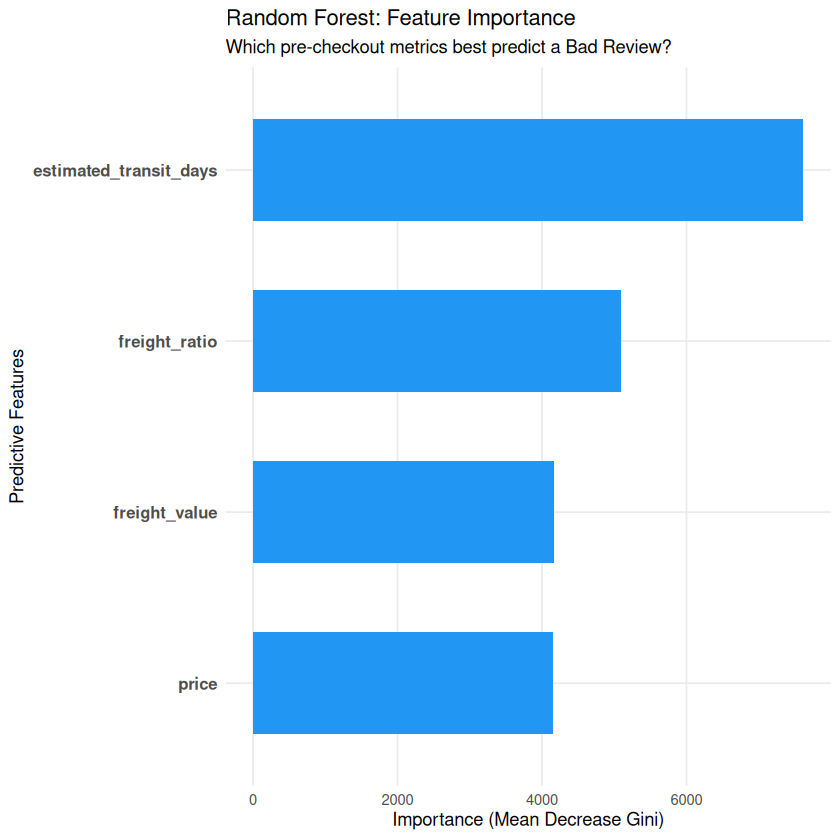

In [44]:
library(randomForest)

# 1. Prepare Pre-Checkout Features (What Olist knows before the sale is finalized)
rf_data <- item_sales_data %>%
  filter(!is.na(order_estimated_delivery_date), !is.na(order_purchase_timestamp)) %>%
  inner_join(clean_reviews, by = "order_id") %>%
  mutate(
    # Target Variable: "Yes" if Bad Review (1-2 stars), "No" if Good/Neutral (3-5 stars)
    bad_review = as.factor(ifelse(review_score <= 2, "Yes", "No")),
    
    # Feature 1: The logistics promise made to the customer at checkout
    estimated_transit_days = as.numeric(difftime(order_estimated_delivery_date, 
                                                 order_purchase_timestamp, units = "days")),
    # Feature 2: The friction metric we engineered earlier
    freight_ratio = (freight_value / price) * 100
  ) %>%
  # Select purely the target and the pre-checkout numerical features
  select(bad_review, price, freight_value, freight_ratio, estimated_transit_days) %>%
  drop_na()

# 2. Downsampling to prevent memory crash in Codespaces
set.seed(42)
rf_data_sampled <- rf_data %>% sample_n(100000)

# 3. Train/Test Split (80% for learning, 20% for testing)
train_indices <- sample(1:nrow(rf_data_sampled), 0.8 * nrow(rf_data_sampled))
train_data <- rf_data_sampled[train_indices, ]
test_data <- rf_data_sampled[-train_indices, ]

# 4. Train the Random Forest Algorithm
print("Training the Random Forest...")
rf_model <- randomForest(
  bad_review ~ ., 
  data = train_data, 
  ntree = 300,          # Grow 300 decision trees
  importance = TRUE     # Calculate which features matter most
)

# 5. Extract and Plot Feature Importance
importance_df <- as.data.frame(importance(rf_model))
importance_df$Feature <- rownames(importance_df)

ggplot(importance_df, aes(x = reorder(Feature, MeanDecreaseGini), y = MeanDecreaseGini)) +
  geom_col(fill = "#2196F3", width = 0.6) +
  coord_flip() +
  labs(
    title = "Random Forest: Feature Importance",
    subtitle = "Which pre-checkout metrics best predict a Bad Review?",
    x = "Predictive Features",
    y = "Importance (Mean Decrease Gini)"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(face = "bold", size = 10),
    panel.grid.minor = element_blank()
  )

ggsave("random_forest_importance.png", width = 10, height = 6, dpi = 300)

In [45]:
# 1. Force the model to predict the outcomes of the unseen TEST data
print("Running predictions on the test set...")
rf_predictions <- predict(rf_model, newdata = test_data)

# 2. Build a Confusion Matrix to compare Predictions vs. Reality
confusion_matrix <- table(Predicted = rf_predictions, Actual = test_data$bad_review)
print("--- Confusion Matrix ---")
print(confusion_matrix)

# 3. Calculate Overall Accuracy
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)
print(paste("Overall Model Accuracy:", round(accuracy * 100, 2), "%"))

# 4. Calculate Precision and Recall for the "Yes" (Bad Review) class
true_positive <- confusion_matrix["Yes", "Yes"]
false_positive <- confusion_matrix["Yes", "No"]
false_negative <- confusion_matrix["No", "Yes"]

precision <- true_positive / (true_positive + false_positive)
recall <- true_positive / (true_positive + false_negative)

print(paste("Precision (When it predicts a bad review, how often is it right?):", round(precision * 100, 2), "%"))
print(paste("Recall (Out of all actual bad reviews, how many did it catch?):", round(recall * 100, 2), "%"))

[1] "Running predictions on the test set..."
[1] "--- Confusion Matrix ---"
         Actual
Predicted    No   Yes
      No  16278  2453
      Yes   396   873
[1] "Overall Model Accuracy: 85.76 %"
[1] "Precision (When it predicts a bad review, how often is it right?): 68.79 %"
[1] "Recall (Out of all actual bad reviews, how many did it catch?): 26.25 %"


In [47]:
install.packages("pROC")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




[1] "Extracting probabilities from the Random Forest..."


Setting direction: controls < cases



[1] "--- Final Model Performance ---"
[1] "Area Under the ROC Curve (AUC): 0.6757"


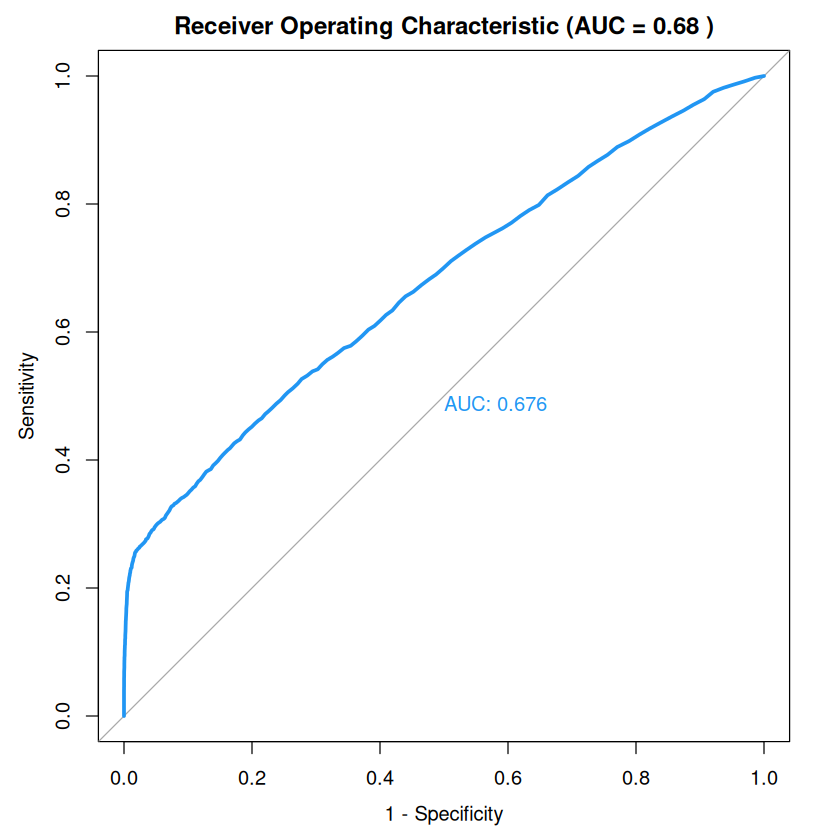

In [48]:
# install.packages("pROC")
library(pROC)

# 1. Ask the model for PROBABILITIES, not just hard classes
print("Extracting probabilities from the Random Forest...")
rf_probabilities <- predict(rf_model, newdata = test_data, type = "prob")

# 2. Isolate the probability specifically for the "Yes" (Bad Review) class
prob_bad_review <- rf_probabilities[, "Yes"]

# 3. Calculate the ROC Curve and AUC
roc_curve <- roc(test_data$bad_review, prob_bad_review, levels = c("No", "Yes"))
auc_value <- auc(roc_curve)

print("--- Final Model Performance ---")
print(paste("Area Under the ROC Curve (AUC):", round(auc_value, 4)))

# 4. Plot the ROC Curve
plot(roc_curve, 
     main = paste("Receiver Operating Characteristic (AUC =", round(auc_value, 2), ")"), 
     col = "#2196F3", 
     lwd = 3,
     print.auc = TRUE,
     legacy.axes = TRUE) # Makes the X-axis show False Positive Rate (0 to 1)